In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import matplotlib
import seaborn as sns
import scanpy as sc
import scipy.stats as stats
import openpyxl
import os
import warnings
warnings.filterwarnings("ignore")

/home/reinert/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/reinert/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/reinert/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/reinert/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/reinert/.local/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing re

## Load Spatial Object and Collapse Cell Types - NEW 480

In [2]:
adata = sc.read_h5ad('/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/resolvi_objs/480SAMPLES_KPMP_TISAC_annotated_integrated_obj.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 1417699 × 480
    obs: 'cell_id', 'n_counts', 'total_counts', 'n_genes_by_counts', 'sample', 'ppid', 'dx', 'assay', 'organ', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'leiden', 'v2.subclass.l1', 'v2.subclass.l2', 'v2.subclass.l3', 'v2.subclass.levelKIL', 'spatial_celltype'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'annotation_colors', 'neighbors', 'sample_colors', 'umap'
    obsm: 'X_resolVI', 'X_spatial', 'X_umap', 'distance_neighbor', 'index_neighbor', 'spatial'
   

In [4]:
adata.obs.rename(columns={"annotation": "v2.subclass.l3"}, inplace=True)

In [5]:
adata.obs['cell_type_collapsed'] = adata.obs['v2.subclass.l3'].astype(str)

# collapse frPT subtypes
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(['frPT-S1/S2', 'frPT-S3']),
              'cell_type_collapsed'] = 'frPT'

# collapse PT-S1 and PT-S2
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(['PT-S1', 'PT-S2']),
              'cell_type_collapsed'] = 'PT-S1/S2'

# collapse FIB subtypes
fib_types = ['OM-FIB', 'C/M-FIB', 'dIM-FIB', 'IM-FIB', 'C-FIB-OSMRhi',
             'C-FIB-PATH', 'dFIB', 'C-FIB', 'C-FIB-OSMRlo', 'pvFIB',
             'C-MYOF', 'pvFIB-RSPO3+', 'dOM-FIB', 'pvFIB-PI16+',
             'IM-pvMYOF', 'pvMYOF']
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(fib_types),
              'cell_type_collapsed'] = 'FIB'

# collapse IMM subtypes
imm_types = ['resMAC-LYVE1+', 'MON', 'CD8+ TEM/TRM', 'B', 'cDC2', 'Naïve Th',
             'NK', 'MAST', 'resMAC-HLAIIhi', 'MAIT', 'pDC', 'cDC1', 'ncMON',
             'T-REG', 'moMAC-HBEGF+', 'cycT', 'ILC3', 'moMAC-CXCL10+',
             'CD8+ TEM/TEMRA', 'mDC', 'moMAC-C3+', 'cycMAC', 'moFAM']
adata.obs.loc[adata.obs['v2.subclass.l3'].isin(imm_types),
              'cell_type_collapsed'] = 'IMM'

# subset to cell types of interest
cell_types_to_keep = ['aPT1', 'aPT2', 'aPT-S1/S2', 'frPT', 'PT-S1/S2', 'FIB', 'IMM']
adata_subset = adata[adata.obs['cell_type_collapsed'].isin(cell_types_to_keep)].copy()

print(f"Subset: {adata_subset.n_obs} cells")
print(adata_subset.obs['cell_type_collapsed'].value_counts().sort_index())

Subset: 570715 cells
cell_type_collapsed
FIB          231558
IMM          144929
PT-S1/S2     130302
aPT-S1/S2     17156
aPT1          20157
aPT2          12518
frPT          14095
Name: count, dtype: int64


## Obtain Marker Genes from Atlas Object (Differential Expression)

In [6]:
atlas = sc.read_h5ad('/storage2/fs1/sanjayjain/Active/Stephanie/objects/Kidney_Atlas_V2_05162024_Object.h5ad')

In [7]:
# subset atlas to PT cell types
pt_types = ['PT-S1', 'PT-S2', 'PT-S3', 'aPT-S1/S2', 'aPT-S3',
            'aPT1', 'aPT2', 'frPT-S1/S2', 'frPT-S3']
atlas_pt = atlas[atlas.obs['v2.subclass.l3'].isin(pt_types)].copy()

# grouping
atlas_pt.obs['pt_status'] = 'other'
atlas_pt.obs.loc[atlas_pt.obs['v2.subclass.l3'].isin(['PT-S1', 'PT-S2', 'PT-S3']),
                 'pt_status'] = 'healthy_PT'
atlas_pt.obs.loc[atlas_pt.obs['v2.subclass.l3'].isin(['aPT1', 'aPT2']),
                 'pt_status'] = 'altered_PT'

atlas_pt_de = atlas_pt[atlas_pt.obs['pt_status'].isin(['healthy_PT', 'altered_PT'])].copy()

# normalize and log-transform
sc.pp.normalize_total(atlas_pt_de, target_sum=1e4)
sc.pp.log1p(atlas_pt_de)

# differentisl expression (genes upregulated in altered PT vs healthy PT)
sc.tl.rank_genes_groups(atlas_pt_de, groupby='pt_status', method='wilcoxon',
                         reference='healthy_PT', groups=['altered_PT'])

# get significant upregulated genes, filter to spatial gene panel, exclude SOX4/SOX9 for analysis
result_injury = sc.get.rank_genes_groups_df(atlas_pt_de, group='altered_PT')
result_injury = result_injury[result_injury['pvals_adj'] < 0.05]
result_injury = result_injury[result_injury['logfoldchanges'] > 0]
in_panel = result_injury[result_injury['names'].isin(adata.var_names)]
in_panel = in_panel[~in_panel['names'].isin(['SOX4', 'SOX9'])]

print(f"Significant injury genes in Xenium panel: {len(in_panel)}")
print("\nTop 20:")
print(in_panel.head(20)[['names', 'logfoldchanges', 'pvals_adj', 'scores']].to_string())

# final injury signature
injury_sig = in_panel.head(20)['names'].tolist()

# check removal SOX4/SOX9 
injury_sig = [g for g in injury_sig if g not in ['SOX4', 'SOX9']]
print(f"Final injury signature ({len(injury_sig)} genes): {injury_sig}")

Significant injury genes in Xenium panel: 245

Top 20:
      names  logfoldchanges  pvals_adj      scores
0     ITGB8        2.859572        0.0  179.848892
2     DCDC2        2.457622        0.0  140.492172
3       DCC        4.761828        0.0  135.644211
4      RHEX        2.107570        0.0  134.439392
5     MACC1        2.466122        0.0  132.353333
6     STOX2        2.090072        0.0  128.570312
10    CREB5        2.189390        0.0  118.974281
12    PROM1        3.660499        0.0  116.318329
16   CASC15        3.443506        0.0  108.155594
23   COL4A1        1.829064        0.0  102.731499
27    VCAM1        2.972253        0.0   99.896721
29   DLGAP1        2.891698        0.0   98.094032
35     KLF6        1.850494        0.0   95.965881
38      MET        1.639600        0.0   94.688614
45  TNFSF10        1.676015        0.0   89.738037
49   KCTD16        2.999028        0.0   88.887794
61   COL4A2        1.183180        0.0   84.572403
62   HAVCR1        2.532679

## Score and Reclassify aPT1 and aPT2 in Spatial

In [8]:
# score each cell on injury signature (how strongly it expresses selected injury genes)
# cells above median get labeled aPT2, cells below median get labeled aPT1

# subset to only aPT1 and aPT2 cells
apt_mask = adata_subset.obs['cell_type_collapsed'].isin(['aPT1', 'aPT2'])
adata_apt = adata_subset[apt_mask].copy()
print(f"aPT1: {(adata_apt.obs['cell_type_collapsed'] == 'aPT1').sum()}")
print(f"aPT2: {(adata_apt.obs['cell_type_collapsed'] == 'aPT2').sum()}")

# score
injury_sig_final = [g for g in injury_sig if g in adata_subset.var_names]
print(f"Injury signature in panel ({len(injury_sig_final)} genes): {injury_sig_final}")
sc.tl.score_genes(adata_apt, gene_list=injury_sig_final, score_name='injury_score')

# higher injury = aPT2 (early injury), lower = aPT1 (resolving)
median_score = adata_apt.obs['injury_score'].median()
adata_apt.obs['suggested_label'] = np.where(
    adata_apt.obs['injury_score'] > median_score, 'aPT2', 'aPT1')

aPT1: 20157
aPT2: 12518
Injury signature in panel (20 genes): ['ITGB8', 'DCDC2', 'DCC', 'RHEX', 'MACC1', 'STOX2', 'CREB5', 'PROM1', 'CASC15', 'COL4A1', 'VCAM1', 'DLGAP1', 'KLF6', 'MET', 'TNFSF10', 'KCTD16', 'COL4A2', 'HAVCR1', 'SOD2', 'IL32']


## Check Results

In [9]:
# for each aPT1 and aPT2 cell type, see the average SOX4 and SOX9 expression
# original labels versus corrected labels

print("SOX4/SOX9 VALIDATION")
print("\nOriginal:")
for ct in ['aPT1', 'aPT2']:
    mask = adata_apt.obs['cell_type_collapsed'] == ct
    sox4 = float(np.asarray(adata_apt[mask, 'SOX4'].X.mean()))
    sox9 = float(np.asarray(adata_apt[mask, 'SOX9'].X.mean()))
    print(f"  {ct}: SOX4={sox4:.3f}, SOX9={sox9:.3f}")

print("\nCorrected:")
for ct in ['aPT1', 'aPT2']:
    mask = adata_apt.obs['suggested_label'] == ct
    sox4 = float(np.asarray(adata_apt[mask, 'SOX4'].X.mean()))
    sox9 = float(np.asarray(adata_apt[mask, 'SOX9'].X.mean()))
    print(f"  {ct}: SOX4={sox4:.3f}, SOX9={sox9:.3f}")

SOX4/SOX9 VALIDATION

Original:
  aPT1: SOX4=2.452, SOX9=1.234
  aPT2: SOX4=1.069, SOX9=0.531

Corrected:
  aPT1: SOX4=0.535, SOX9=0.273
  aPT2: SOX4=3.310, SOX9=1.657


In [10]:
# confusion matrix to check
confusion = pd.crosstab(adata_apt.obs['cell_type_collapsed'],
                         adata_apt.obs['suggested_label'], margins=True)

print("CONFUSION MATRIX")
print(confusion)

print("\nPER-SAMPLE RECLASSIFICATION")
switch_by_sample = adata_apt.obs.groupby('sample').apply(
    lambda x: pd.Series({
        'total': len(x),
        'switched': (x['cell_type_collapsed'] != x['suggested_label']).sum(),
        'pct_switched': (x['cell_type_collapsed'] != x['suggested_label']).mean() * 100
    })
)
print(switch_by_sample.to_string())

print("\nSUMMARY")
for ct in ['aPT1', 'aPT2']:
    mask = adata_apt.obs['cell_type_collapsed'] == ct
    n = mask.sum()
    same = (adata_apt.obs.loc[mask, 'suggested_label'] == ct).sum()
    print(f"{ct}: {same}/{n} ({same/n*100:.1f}%) retain, "
          f"{n-same}/{n} ({(n-same)/n*100:.1f}%) switch")

CONFUSION MATRIX
suggested_label       aPT1   aPT2    All
cell_type_collapsed                     
aPT1                  7714  12443  20157
aPT2                  8629   3889  12518
All                  16343  16332  32675

PER-SAMPLE RECLASSIFICATION
                   total  switched  pct_switched
sample                                          
xen31_3781        3431.0    2124.0     61.906150
xen31_3990        7289.0    3410.0     46.782823
xen31_KPMP038     1771.0    1342.0     75.776398
xen32_KPMP101     1403.0     850.0     60.584462
xen37_28-12510     153.0      99.0     64.705882
xen37_29-10395     659.0     512.0     77.693475
xen37_31-10105     939.0     702.0     74.760383
xen37_31-10236    1197.0    1016.0     84.878864
xen38_164-17       176.0      93.0     52.840909
xen38_31-10100     984.0     692.0     70.325203
xen41_164-21       261.0      99.0     37.931034
xen41_29-10010     523.0     419.0     80.114723
xen41_29-10404     909.0     728.0     80.088009
xen41_935-1054

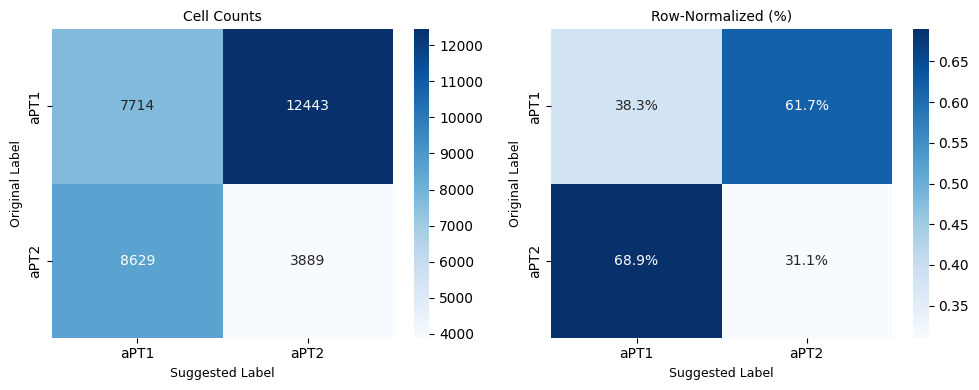

In [11]:
# plot for ease
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# counts
conf_counts = pd.crosstab(adata_apt.obs['cell_type_collapsed'],
                            adata_apt.obs['suggested_label'])
conf_counts = conf_counts.loc[['aPT1', 'aPT2'], ['aPT1', 'aPT2']]

# row normalized 
conf_norm = pd.crosstab(adata_apt.obs['cell_type_collapsed'],
                          adata_apt.obs['suggested_label'], normalize='index')
conf_norm = conf_norm.loc[['aPT1', 'aPT2'], ['aPT1', 'aPT2']]

sns.heatmap(conf_counts, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Suggested Label', fontsize=9)
axes[0].set_ylabel('Original Label', fontsize=9)
axes[0].set_title('Cell Counts', fontsize=10)

sns.heatmap(conf_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Suggested Label', fontsize=9)
axes[1].set_ylabel('Original Label', fontsize=9)
axes[1].set_title('Row-Normalized (%)', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_final_NEWNEW.png', dpi=300, bbox_inches='tight')
plt.show()

## Update Labels

In [12]:
# update aPT1/aPT2 labels
adata.obs['cell_type_corrected_collapsed'] = adata.obs['cell_type_collapsed'].astype(str).copy()
adata.obs.loc[adata_apt.obs.index, 'cell_type_corrected_collapsed'] = adata_apt.obs['suggested_label']

adata_subset.obs['cell_type_corrected_collapsed'] = \
    adata.obs.loc[adata_subset.obs.index, 'cell_type_corrected_collapsed']

print(adata.obs.loc[adata.obs['cell_type_corrected_collapsed'].isin(
    ['aPT1', 'aPT2']), 'cell_type_corrected_collapsed'].value_counts())

cell_type_corrected_collapsed
aPT1    16343
aPT2    16332
Name: count, dtype: int64


## Heatmap

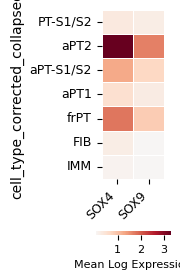

In [13]:
# plot heatmap fig
measured_tfs = ['SOX4', 'SOX9']
cell_types_to_display = ['PT-S1/S2', 'aPT2', 'aPT-S1/S2', 'aPT1', 'frPT', 'FIB', 'IMM']

tf_expr_all = sc.get.obs_df(adata, keys=measured_tfs + ['cell_type_corrected_collapsed'])
mean_expr_all = tf_expr_all.groupby('cell_type_corrected_collapsed')[measured_tfs].mean()
mean_expr_display = mean_expr_all.loc[cell_types_to_display]

plt.figure(figsize=(2, 3))
ax = sns.heatmap(mean_expr_display,
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Mean Log Expression', 'shrink': 1.2,
                      'orientation': 'horizontal', 'pad': 0.2},
            linewidths=0.5,
            annot=False)
ax.collections[0].colorbar.ax.tick_params(labelsize=8)
ax.collections[0].colorbar.set_label('Mean Log Expression', fontsize=8)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('TF_heatmap_corrected_final_NEWNEW.png', dpi=300, bbox_inches='tight')
plt.show()

## Reordered

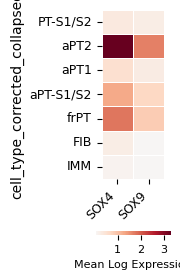

In [14]:
cell_types_to_display = ['PT-S1/S2', 'aPT2', 'aPT1', 'aPT-S1/S2', 'frPT', 'FIB', 'IMM']

tf_expr_all = sc.get.obs_df(adata, keys=measured_tfs + ['cell_type_corrected_collapsed'])
mean_expr_all = tf_expr_all.groupby('cell_type_corrected_collapsed')[measured_tfs].mean()
mean_expr_display = mean_expr_all.loc[cell_types_to_display]

plt.figure(figsize=(2, 3))
ax = sns.heatmap(mean_expr_display,
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Mean Log Expression', 'shrink': 1.2,
                      'orientation': 'horizontal', 'pad': 0.2},
            linewidths=0.5,
            annot=False)
ax.collections[0].colorbar.ax.tick_params(labelsize=8)
ax.collections[0].colorbar.set_label('Mean Log Expression', fontsize=8)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()

# save
plt.savefig('TF_heatmap_final_NEWNEW.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('TF_heatmap_final_NEWNEW.svg', dpi=300, bbox_inches='tight', format='svg')
plt.show()

In [15]:
# print values and cell counts
source_heatmap = mean_expr_display.round(4)
source_heatmap.to_csv('source_data_fig_TF_heatmap_NEWNEW.csv')
print(source_heatmap)

cell_counts = adata.obs.loc[
    adata.obs['cell_type_corrected_collapsed'].isin(cell_types_to_display),
    'cell_type_corrected_collapsed'
].value_counts().loc[cell_types_to_display]
cell_counts.to_csv('source_data_fig_cell_counts_NEWNEW.csv')
print(cell_counts)

                                 SOX4    SOX9
cell_type_corrected_collapsed                
PT-S1/S2                       0.3172  0.2453
aPT2                           3.3102  1.6574
aPT1                           0.5348  0.2728
aPT-S1/S2                      1.2499  0.6914
frPT                           1.7761  0.8545
FIB                            0.2405  0.0352
IMM                            0.1313  0.0296
cell_type_corrected_collapsed
PT-S1/S2     130302
aPT2          16332
aPT1          16343
aPT-S1/S2     17156
frPT          14095
FIB          231558
IMM          144929
Name: count, dtype: int64
